# 01. Intro Dataset: MovieLens Latest Small

Это первый notebook core-маршрута. Здесь мы знакомимся с учебным датасетом, приводим его к канонической схеме interaction table и разбираем базовые свойства данных.

## Что изучим

- почему для первых экспериментов выбран `MovieLens latest small`;
- какие таблицы входят в датасет;
- как получить каноническую interaction table с колонками `user_id`, `item_id`, `rating`, `timestamp`;
- насколько данные разрежены (`sparsity`);
- как выглядят распределения рейтингов, активности пользователей и популярности фильмов;
- какой у датасета временной диапазон и что это значит для следующих notebook'ов.


## Где должны лежать данные

Для этого notebook ожидается ручная загрузка `MovieLens latest small` в директорию `data/raw/movielens/`.

Ожидаемая раскладка:

```text
data/raw/movielens/
├── links.csv
├── movies.csv
├── ratings.csv
└── tags.csv
```

Подробная инструкция лежит в `data/raw/movielens/README.md`.

Если CSV ещё не скачаны, notebook всё равно отработает без traceback, но аналитические ячейки пропустит и покажет, что именно нужно положить в проект.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
from recsys_basics.data import (
    REQUIRED_MOVIELENS_FILES,
    build_explicit_interactions,
    expected_movielens_layout,
    find_missing_files,
    get_movielens_data_dir,
    load_movielens_frames,
    prepare_movielens_movies,
)

DATA_DIR = get_movielens_data_dir()
missing_files = find_missing_files(DATA_DIR, REQUIRED_MOVIELENS_FILES)
DATA_READY = not missing_files

print(f"Папка с данными: {DATA_DIR}")
if DATA_READY:
    print("Обязательные файлы найдены. Можно выполнять анализ.")
else:
    print("Обязательные файлы пока не найдены.")
    print(expected_movielens_layout(DATA_DIR))
    print("См. также data/raw/movielens/README.md")


Папка с данными: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/movielens
Обязательные файлы найдены. Можно выполнять анализ.


## Какие таблицы есть в MovieLens

Для первых notebook'ов нам важны две таблицы:

- `ratings.csv`: пользователь, фильм, рейтинг и время взаимодействия;
- `movies.csv`: название фильма и жанры.

Дополнительно в датасете есть:

- `tags.csv`: пользовательские теги;
- `links.csv`: внешние идентификаторы.

Для темы data/introduction этого достаточно: мы пока не строим модель, а только разбираем структуру и свойства данных.


In [3]:
def require_data() -> bool:
    if DATA_READY:
        return True
    print("Аналитические ячейки ниже пропущены, пока локальные CSV не добавлены.")
    return False


if require_data():
    frames = load_movielens_frames(DATA_DIR)
    ratings_df = frames.ratings
    raw_movies_df = frames.movies
    movies_df = prepare_movielens_movies(raw_movies_df)
    tags_df = frames.tags
    links_df = frames.links

    raw_tables_overview = pd.DataFrame(
        {
            "table": ["ratings", "movies", "tags", "links"],
            "rows": [
                len(ratings_df),
                len(raw_movies_df),
                0 if tags_df is None else len(tags_df),
                0 if links_df is None else len(links_df),
            ],
            "columns": [
                list(ratings_df.columns),
                list(raw_movies_df.columns),
                [] if tags_df is None else list(tags_df.columns),
                [] if links_df is None else list(links_df.columns),
            ],
        }
    )
    display(raw_tables_overview)

    print("ratings.csv")
    display(ratings_df.head())

    print("movies.csv")
    display(raw_movies_df.head())
else:
    frames = None
    ratings_df = pd.DataFrame()
    raw_movies_df = pd.DataFrame()
    movies_df = pd.DataFrame()
    tags_df = None
    links_df = None


,table,rows,columns
0,ratings,100836,"[userId, movieId, rating, timestamp]"
1,movies,9742,"[movieId, title, genres]"
2,tags,3683,"[userId, movieId, tag, timestamp]"
3,links,9742,"[movieId, imdbId, tmdbId]"


ratings.csv


,userId,movieId,rating,timestamp
0,1,1,4.0000,964982703
1,1,3,4.0000,964981247
2,1,6,4.0000,964982224
3,1,47,5.0000,964983815
4,1,50,5.0000,964982931


movies.csv


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Приводим `ratings.csv` к канонической схеме interactions

Во всём проекте мы хотим работать с одной и той же логикой interaction table:

- `user_id`
- `item_id`
- `rating` или `event`
- `timestamp`

В `MovieLens` сигнал относится к `explicit feedback`: пользователь явно поставил оценку фильму. Это не то же самое, что `implicit feedback` вроде просмотра, клика или добавления в корзину.


In [4]:
if require_data():
    interactions_df = build_explicit_interactions(ratings_df)
    display(interactions_df.head())

    schema_check = pd.DataFrame(
        {
            "column": interactions_df.columns,
            "dtype": [str(dtype) for dtype in interactions_df.dtypes],
            "missing_values": interactions_df.isna().sum().tolist(),
        }
    )
    display(schema_check)

    duplicate_rows = interactions_df.duplicated().sum()
    print(f"Полных дубликатов строк: {duplicate_rows}")
else:
    interactions_df = pd.DataFrame()


,user_id,item_id,rating,timestamp
0,429,22,4.0000,1996-03-29 18:36:55+00:00
1,429,150,5.0000,1996-03-29 18:36:55+00:00
2,429,161,5.0000,1996-03-29 18:36:55+00:00
3,429,165,4.0000,1996-03-29 18:36:55+00:00
4,429,218,4.0000,1996-03-29 18:36:55+00:00


,column,dtype,missing_values
0,user_id,int64,0
1,item_id,int64,0
2,rating,float64,0
3,timestamp,"datetime64[s, UTC]",0


Полных дубликатов строк: 0


In [5]:
if require_data():
    n_users = interactions_df["user_id"].nunique()
    n_items = interactions_df["item_id"].nunique()
    n_interactions = len(interactions_df)

    matrix_size = n_users * n_items
    density = n_interactions / matrix_size
    sparsity = 1.0 - density

    user_activity = interactions_df.groupby("user_id").size()
    item_popularity = interactions_df.groupby("item_id").size()

    summary = pd.DataFrame(
        {
            "metric": [
                "users",
                "items",
                "interactions",
                "matrix_size",
                "density",
                "sparsity",
                "avg_interactions_per_user",
                "median_interactions_per_user",
                "avg_interactions_per_item",
                "median_interactions_per_item",
            ],
            "value": [
                n_users,
                n_items,
                n_interactions,
                matrix_size,
                density,
                sparsity,
                user_activity.mean(),
                user_activity.median(),
                item_popularity.mean(),
                item_popularity.median(),
            ],
        }
    )
    display(summary)

    print(
        "Разреженность важна, потому что рекомендательные системы почти всегда работают "
        "с неполной user-item матрицей."
    )


,metric,value
0,users,610.0000
1,items,"9,724.0000"
2,interactions,"100,836.0000"
3,matrix_size,"5,931,640.0000"
4,density,0.0170
5,sparsity,0.9830
6,avg_interactions_per_user,165.3049
7,median_interactions_per_user,70.5000
8,avg_interactions_per_item,10.3698
9,median_interactions_per_item,3.0000


Разреженность важна, потому что рекомендательные системы почти всегда работают с неполной user-item матрицей.


## Распределение рейтингов

На этом шаге полезно понять, как именно пользователи используют шкалу оценок. Это влияет на baseline, на порог бинаризации и на то, как мы будем интерпретировать сигнал дальше.


,interaction_count
rating,
0.5000,1370
1.0000,2811
1.5000,1791
2.0000,7551
2.5000,5550
3.0000,20047
3.5000,13136
4.0000,26818
4.5000,8551


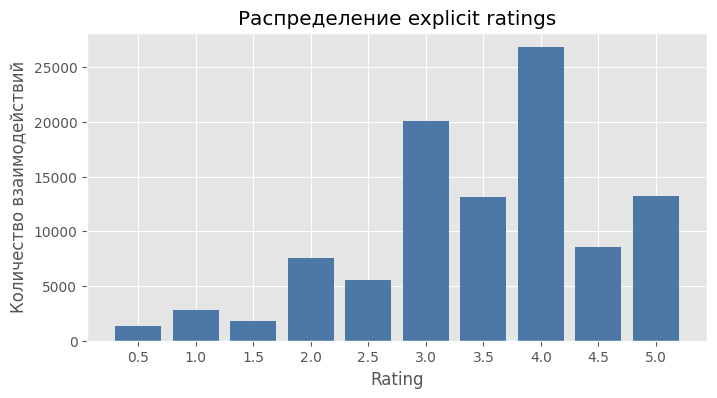

In [6]:
if require_data():
    rating_distribution = interactions_df["rating"].value_counts().sort_index()
    display(rating_distribution.rename("interaction_count").to_frame())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(rating_distribution.index.astype(str), rating_distribution.values, color="#4C78A8")
    ax.set_title("Распределение explicit ratings")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Количество взаимодействий")
    plt.show()


## Активность пользователей и long-tail по фильмам

Обычно в recsys часть пользователей очень активна, а большая часть объектов получает мало взаимодействий. Это и есть один из типичных long-tail паттернов.


,metric,value
0,p50_user_interactions,70
1,p90_user_interactions,400
2,p99_user_interactions,1260
3,p50_item_interactions,3
4,p90_item_interactions,27
5,p99_item_interactions,115
6,share_of_interactions_from_top_10pct_items,60.02%


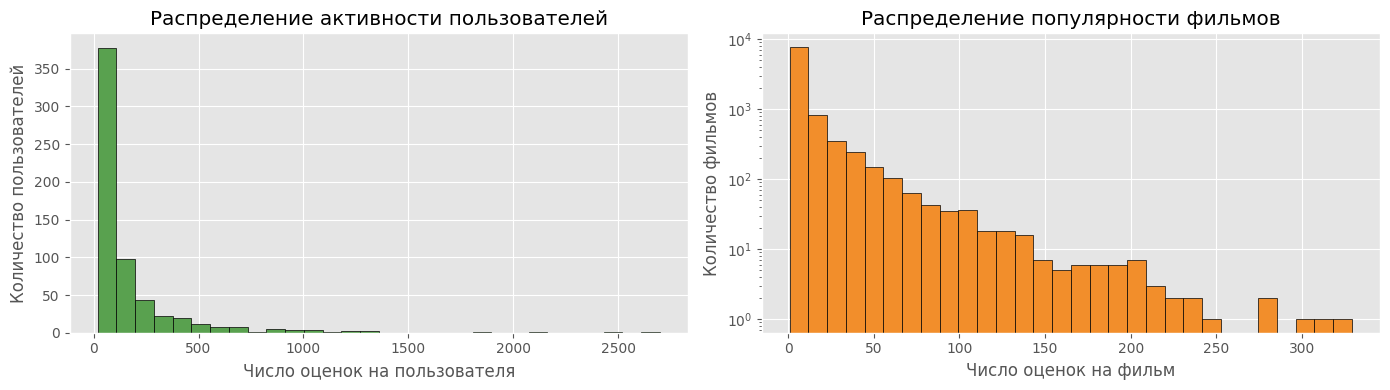

In [7]:
if require_data():
    user_activity = interactions_df.groupby("user_id").size().sort_values(ascending=False)
    item_popularity = interactions_df.groupby("item_id").size().sort_values(ascending=False)

    top_10pct_items = max(1, int(len(item_popularity) * 0.10))
    top_10pct_share = item_popularity.head(top_10pct_items).sum() / item_popularity.sum()

    long_tail_summary = pd.DataFrame(
        {
            "metric": [
                "p50_user_interactions",
                "p90_user_interactions",
                "p99_user_interactions",
                "p50_item_interactions",
                "p90_item_interactions",
                "p99_item_interactions",
                "share_of_interactions_from_top_10pct_items",
            ],
            "value": [
                int(user_activity.quantile(0.50, interpolation="nearest")),
                int(user_activity.quantile(0.90, interpolation="nearest")),
                int(user_activity.quantile(0.99, interpolation="nearest")),
                int(item_popularity.quantile(0.50, interpolation="nearest")),
                int(item_popularity.quantile(0.90, interpolation="nearest")),
                int(item_popularity.quantile(0.99, interpolation="nearest")),
                f"{top_10pct_share:.2%}",
            ],
        }
    )
    display(long_tail_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(user_activity, bins=30, color="#59A14F", edgecolor="black")
    axes[0].set_title("Распределение активности пользователей")
    axes[0].set_xlabel("Число оценок на пользователя")
    axes[0].set_ylabel("Количество пользователей")

    axes[1].hist(item_popularity, bins=30, color="#F28E2B", edgecolor="black")
    axes[1].set_title("Распределение популярности фильмов")
    axes[1].set_xlabel("Число оценок на фильм")
    axes[1].set_ylabel("Количество фильмов")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()


## Что можно увидеть через метаданные фильмов

Даже в intro-ноутбуке полезно быстро посмотреть на названия и жанры: это мост к следующей теме про content-based признаки.


,item_id,interaction_count,title,genres,title_year
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War,1994
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama,1994
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,1991
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller,1999
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,1977
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,1993
97,110,237,Braveheart (1995),Action|Drama|War,1995
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi,1991
461,527,220,Schindler's List (1993),Drama|War,1993


,movie_count
genre_list,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978


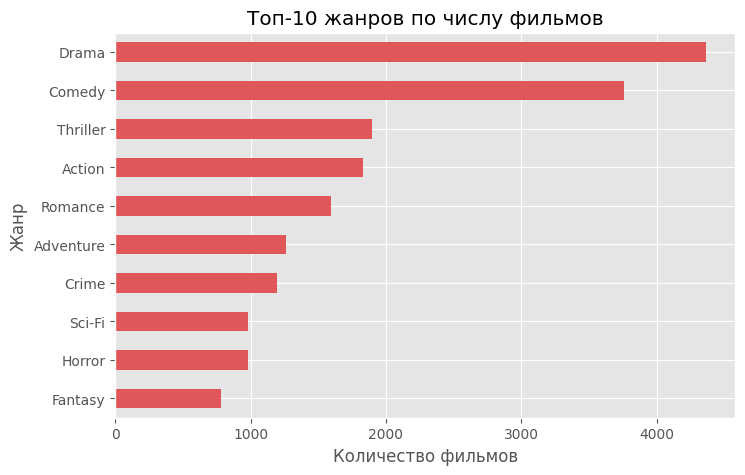

In [8]:
if require_data():
    most_rated_movies = (
        interactions_df.groupby("item_id")
        .size()
        .rename("interaction_count")
        .reset_index()
        .merge(movies_df[["item_id", "title", "genres", "title_year"]], on="item_id", how="left")
        .sort_values("interaction_count", ascending=False)
        .head(10)
    )
    display(most_rated_movies)

    genre_distribution = (
        movies_df.explode("genre_list")
        .query("genre_list != '' and genre_list != '(no genres listed)'")
        .groupby("genre_list")
        .size()
        .sort_values(ascending=False)
    )
    display(genre_distribution.head(10).rename("movie_count").to_frame())

    fig, ax = plt.subplots(figsize=(8, 5))
    genre_distribution.head(10).sort_values().plot.barh(ax=ax, color="#E15759")
    ax.set_title("Топ-10 жанров по числу фильмов")
    ax.set_xlabel("Количество фильмов")
    ax.set_ylabel("Жанр")
    plt.show()


## Временной диапазон

Для рекомендаций время важно почти всегда. Даже если в следующих notebook'ах мы начнём с простых baseline-моделей, уже здесь полезно увидеть, что взаимодействия имеют порядок и происходят не одновременно.


,metric,value
0,first_interaction,1996-03-29 18:36:55+00:00
1,last_interaction,2018-09-24 14:27:30+00:00
2,time_span_days,8213
3,months_in_time_span,271
4,months_with_interactions,267
5,months_without_interactions,4


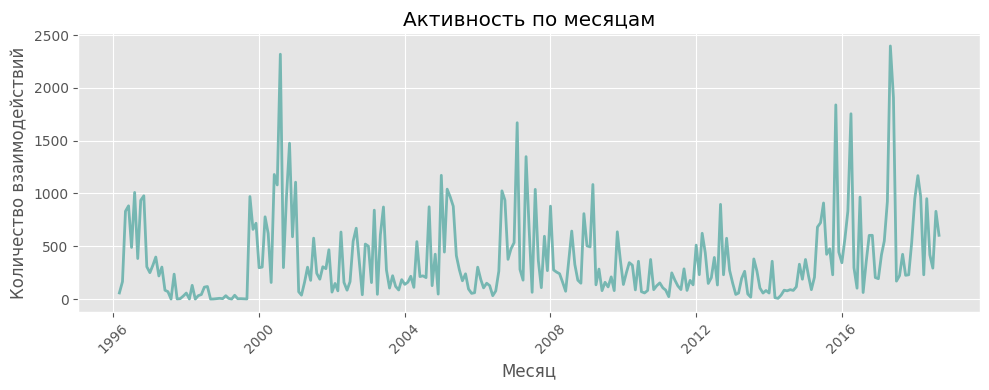

In [9]:
if require_data():
    monthly_activity = interactions_df.set_index("timestamp").resample("MS").size()
    active_months = int((monthly_activity > 0).sum())
    months_in_time_span = int(len(monthly_activity))
    zero_months = months_in_time_span - active_months

    temporal_summary = pd.DataFrame(
        {
            "metric": [
                "first_interaction",
                "last_interaction",
                "time_span_days",
                "months_in_time_span",
                "months_with_interactions",
                "months_without_interactions",
            ],
            "value": [
                interactions_df["timestamp"].min(),
                interactions_df["timestamp"].max(),
                (interactions_df["timestamp"].max() - interactions_df["timestamp"].min()).days,
                months_in_time_span,
                active_months,
                zero_months,
            ],
        }
    )
    display(temporal_summary)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(monthly_activity.index, monthly_activity.values, color="#76B7B2", linewidth=2)
    ax.set_title("Активность по месяцам")
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Количество взаимодействий")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Что получилось

После этого notebook должно быть понятно:

- из каких таблиц состоит `MovieLens latest small`;
- как из `ratings.csv` получить каноническую interaction table;
- что данные сильно разрежены, а активность и популярность распределены неравномерно;
- что у датасета есть временная структура, поэтому тему split нельзя игнорировать;
- что `movies.csv` уже содержит полезные признаки для content-based подхода.

## Что дальше

Следующий шаг в core-маршруте: `02_popularity_baseline.ipynb`. Там мы построим самую простую модель рекомендаций и получим точку отсчёта для всех следующих подходов.
